# Homework

## Part 1

### Considerations

1. Labeling threshold  
    Define the decision threshold for mapping continuous predictions to binary labels.

2. Normalization of objective terms  
    - Term 1 (labeled–unlabeled consistency): divide by the number of labeled samples L.  
    - Term 2 (unlabeled–unlabeled consistency): divide by 2U (twice the number of unlabeled samples) to avoid double counting.

3. Similarity function selection  
    Choose and parameterize a kernel or distance measure (e.g. RBF kernel, Euclidean distance) for computing  
    W and W_tilde.

4. BCGD step‐size & priority rules  
    - Step‐size options: global Lipschitz constant, block‐wise Lipschitz constant or exact line search.  
    - Priority criteria: absolute gradient magnitude, normalized gradient or estimated maximum improvement.

In [14]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import rbf_kernel, euclidean_distances
from abc import ABC, abstractmethod
from typing import List, Callable

### Dataset generation

In [15]:
def generate_dataset(n_samples: int = 200, labeled_ratio: float = 0.1, centers: List = [[0, 0], [3, 3]], cluster_std: float = 1.0, random_state: int = 42):
    """
    Generate a binary classification dataset for semi-supervised learning

    Parameters:
    -----------
    n_samples: int
        Total number of samples
    labeled_ratio: float
        Ratio of labeled examples (between 0 and 1)
    centers: array-like of shape (2, 2)
        The centers of the two clusters
    cluster_std: float or list of two floats
        The standard deviation of the clusters
    random_state: int
        Random seed for reproducibility
        
    Returns:
    --------
    X_labeled: array of shape (n_labeled, 2)
        Labeled examples
    y_labeled: array of shape (n_labeled,)
        Labels for labeled examples
    X_unlabeled: array of shape (n_samples - n_labeled, 2)
        Unlabeled examples
    y_true: array of shape (n_samples - n_labeled,)
        True labels for unlabeled examples (for evaluation)
    """
    np.random.seed(random_state)
    
    # Calculate number of labeled examples
    n_labeled = int(n_samples * labeled_ratio)
    
    centers = np.array(centers)
    assert centers.shape == (2, 2), "Centers must be a 2x2 array"
    
    # Handle cluster_std as scalar or list
    if np.isscalar(cluster_std):
        cluster_std = [cluster_std, cluster_std]

    # Generate samples per class
    n_per_cluster = n_samples // 2
    remainder = n_samples - 2 * n_per_cluster
    samples_per_cluster = [n_per_cluster, n_per_cluster + remainder]

    # Generate data
    X1 = np.random.randn(samples_per_cluster[0], 2) * cluster_std[0] + centers[0]
    y1 = np.zeros(samples_per_cluster[0])
    
    X2 = np.random.randn(samples_per_cluster[1], 2) * cluster_std[1] + centers[1]
    y2 = np.ones(samples_per_cluster[1])
    
    # Combine the clusters
    X = np.vstack([X1, X2])
    y = np.hstack([y1, y2])
    
    # Shuffle the data
    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]
    
    # Split into labeled and unlabeled sets
    X_labeled = X[:n_labeled]
    y_labeled = y[:n_labeled]
    X_unlabeled = X[n_labeled:]
    y_true = y[n_labeled:]
    
    return X_labeled, y_labeled, X_unlabeled, y_true

In [16]:
def calculate_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.mean(y_true == y_pred)

def plot_dataset(X_labeled, y_labeled, X_unlabeled, y_pred=None, y_true=None):
    plt.figure(figsize=(12, 5))

    # Plot data before labeling
    plt.subplot(1, 2, 1)
    plt.scatter(
        X_labeled[:, 0], X_labeled[:, 1], 
        c=y_labeled, 
        cmap='coolwarm',
        marker='o', edgecolors='k'
    )
    plt.scatter(
        X_unlabeled[:, 0], X_unlabeled[:, 1],
        c='gray', marker='.'
    )
    plt.title('Labeled and Unlabeled Examples')

    # Plot data after labeling (if available)
    if y_pred is not None:
        plt.subplot(1, 2, 2)
        plt.scatter(
            X_labeled[:, 0], X_labeled[:, 1], 
            c=y_labeled, 
            cmap='coolwarm',
            marker='o', edgecolors='k'
        )
        plt.scatter(
            X_unlabeled[:, 0], X_unlabeled[:, 1], 
            c=y_pred, 
            cmap='coolwarm', marker='.'
        )

        accuracy = None
        if y_true is not None:
            accuracy = calculate_accuracy(y_true, y_pred)
            plt.title(f'Predicted Labels (Accuracy: {accuracy:.2f})')
        else:
            plt.title('Predicted Labels')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_metrics(solver, figsize=(14, 4), title=None):
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # Plot accuracy over iterations
    axs[0].plot(solver.accuracy_history)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Accuracy')
    axs[0].grid(True, alpha=0.3)

    # Plot loss over iterations
    axs[1].plot(solver.loss_history)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Loss')
    axs[1].grid(True, alpha=0.3)

    # Plot CPU time over iterations
    axs[2].plot(solver.cpu_time_history)
    axs[2].set_xlabel('Iterations')
    axs[2].set_ylabel('CPU Time (s)')
    axs[2].grid(True, alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.tight_layout()
    plt.show()


def compare_solvers(solvers, labels, figsize=(16, 12), log_scale=False):
    fig, axs = plt.subplots(3, 1, figsize=figsize)
    colors = sns.color_palette("husl", len(solvers))

    # Plot accuracy over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[0].plot(solver.accuracy_history, label=label, color=colors[i])
    axs[0].set_title('Accuracy vs Iterations', fontsize=14)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Accuracy')
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Plot loss over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[1].plot(solver.loss_history, label=label, color=colors[i])
    axs[1].set_title('Loss vs Iterations', fontsize=14)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Loss')
    if log_scale:
        axs[1].set_yscale('log')
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    # Plot accuracy vs CPU time
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[2].plot(solver.cpu_time_history, solver.accuracy_history, label=label, color=colors[i])
    axs[2].set_title('Accuracy vs CPU Time', fontsize=14)
    axs[2].set_xlabel('CPU Time (s)')
    axs[2].set_ylabel('Accuracy')
    axs[2].grid(True, alpha=0.3)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

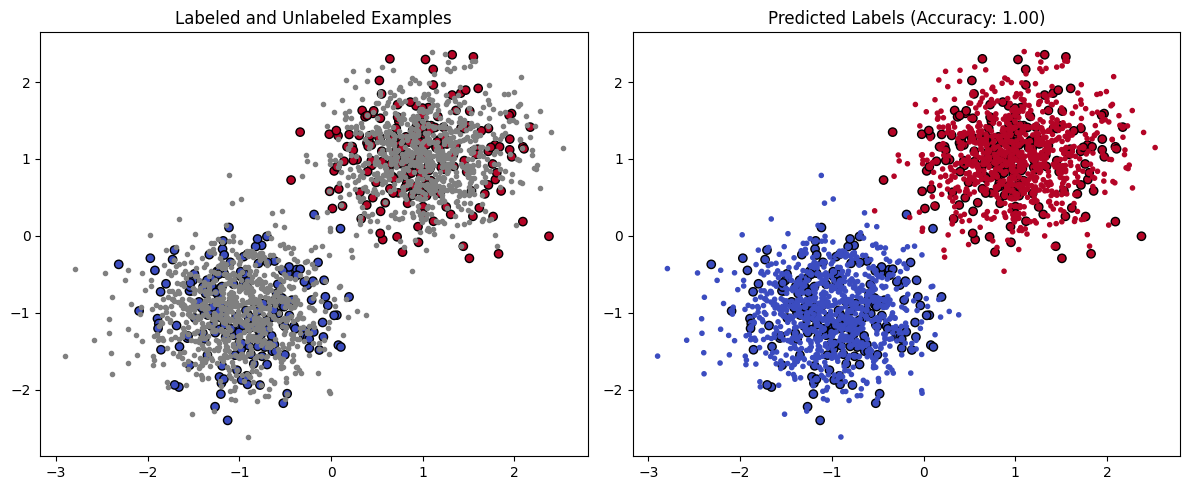

In [18]:
# Generating a dataset
X_labeled, y_labeled, X_unlabeled, y_true = generate_dataset(
    n_samples=2000, 
    labeled_ratio=0.2,
    centers=[[-1, -1], [1, 1]],
    cluster_std=0.5,
    random_state=123
)

# Plotting the dataset
accuracy = plot_dataset(
    X_labeled, y_labeled, X_unlabeled, 
    y_pred=y_true, y_true=y_true
)

### Abstract class for for semi-supervised learning algorithms

Objective function:

∑∑ W[i, j]*(y_pred[j]-y[i])^2 + (1/2)*∑∑ W_tilde[i, j]*(y_pred[i]-y_pred[j])^2

Gradient w.r.t. y_pred[j]:

∇_y_pred[j]_f(y_pred) = 2*∑ W[i, j]*(y_pred[j]-y[i]) + 2*∑ W_tilde[i, j]*(y_pred[j]-y_pred[i])

In [32]:
class SemiSupervisedLearner(ABC):

    def __init__(self, similarity_function: Callable = None, threshold: float = 0.5, max_iter: int = 1000, tol: float = 0.0001):

        self.X_labeled = None
        self.y_labeled = None
        self.X_unlabeled = None
        self.y_pred = None
        self.y_true = None

        self.similarity_function = similarity_function
        self.threshold = threshold
        self.W = None
        self.W_tilde = None

        self.H = None
        self.L = None
        self.diag_H = None
        self.L_block = None

        self.max_iter = max_iter
        self.tol = tol
        self.loss_history = []
        self.accuracy_history = []
        self.cpu_time_history = []

    def fit(self, X_labeled: np.ndarray, y_labeled: np.ndarray,
            X_unlabeled: np.ndarray, y_true: np.ndarray) -> np.ndarray:
        """
        Fit the model and predict labels for unlabeled data

        Parameters:
        -----------
        X_labeled: array of shape (L, d)
            Labeled examples
        y_labeled: array of shape (L,)
            Labels for labeled examples
        X_unlabeled: array of shape (U, d)
            Unlabeled examples
        y_true: array of shape (U,)
            True labels for unlabeled examples (for evaluation)

        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        self.X_labeled = X_labeled
        self.y_labeled = y_labeled
        self.X_unlabeled = X_unlabeled
        self.y_true = y_true

        # Compute similarity matrices
        self.W = self._compute_similarity_labeled_unlabeled()
        self.W_tilde = self._compute_similarity_unlabeled_unlabeled()

        # Initialize predicted labels as zeros
        # self.y_pred = np.zeros(len(self.X_unlabeled))

        # Initialize predicted labels randomly between 0 and 1
        # self.y_pred = np.random.rand(len(self.X_unlabeled))

        # Initialize predicted labels as 0.5
        self.y_pred = np.full(len(self.X_unlabeled), 0.5)

        # Solve the optimization problem
        self.y_pred = self._solve_optimization()

        return self.y_pred

    def _compute_similarity_labeled_unlabeled(self) -> np.ndarray:
        """
        Compute similarity matrix between labeled and unlabeled examples

        Returns:
        --------
        W: array of shape (L, U)
            Similarity matrix between labeled and unlabeled examples
        """
        return self.similarity_function(self.X_labeled, self.X_unlabeled)

    def _compute_similarity_unlabeled_unlabeled(self) -> np.ndarray:
        """
        Compute similarity matrix between unlabeled examples excluding self-similarity

        Returns:
        --------
        W_tilde: array of shape (U, U)
            Similarity matrix between unlabeled examples
        """
        W_tilde = self.similarity_function(self.X_unlabeled, self.X_unlabeled)

        # Set diagonal to zero to exclude self-similarity
        np.fill_diagonal(W_tilde, 0)

        return W_tilde

    @abstractmethod
    def _solve_optimization(self) -> np.ndarray:
        """
        Solve the optimization problem to find labels for unlabeled examples

        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        pass

    def objective_function(self, y_pred: np.ndarray) -> float:
        """
        Compute the objective function value for the current solution

        f(y_pred) = ∑∑ W[i, j]*(y_pred[j]-y[i])^2 + (1/2)*∑∑ W_tilde[i, j]*(y_pred[i]-y_pred[j])^2

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples

        Returns:
        --------
        obj_value: float
            Value of the objective function
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        # Term 1: Unlabeled examples similar to labeled ones get similar labels
        # Divide by L to normalize the term
        term1 = np.sum(self.W * (y_pred[np.newaxis, :] - self.y_labeled[:, np.newaxis])**2)

        # Term 2: Similar unlabeled examples get similar labels
        # Divide by U to normalize the term and by 2 to avoid double counting
        term2 = (1/2) * np.sum(self.W_tilde * (y_pred[np.newaxis, :] - y_pred[:, np.newaxis])**2)

        return term1 + term2

    def _gradient(self, y_pred: np.ndarray, j: int) -> np.ndarray:
        """
        Compute the gradient of the objective function with respect to y_pred[j]

        ∇_y_pred[j]_f(y_pred) = 2*∑ W[i, j]*(y_pred[j]-y[i]) + 2*∑ W_tilde[i, j]*(y_pred[j]-y_pred[i])

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples
        j: int
            Index of the unlabeled example for which to compute the gradient

        Returns:
        --------
        grad: float
            Gradient of the objective function with respect to y_pred[j]
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        # Gradient from Term 1
        grad_term_1 = 2 * np.sum(self.W[:, j] * (y_pred[j] - self.y_labeled))

        # Gradient from Term 2
        grad_term_2 = 2 * np.sum(self.W_tilde[j, :] * (y_pred[j] - y_pred))

        return grad_term_1 + grad_term_2

    def gradient(self, y_pred: np.ndarray) -> np.ndarray:
        """
        Compute the gradient of the objective function

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples

        Returns:
        --------
        grad: array of shape (U,)
            Gradient of the objective function
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        grad = np.zeros(U)

        for j in range(U):
            # Compute the gradient for each unlabeled example
            grad[j] = self._gradient(y_pred, j)

        return grad

    def _hessian(self) -> np.ndarray:
        """
        Compute the Hessian matrix of the objective function

        (i != j): H[i, j] = -2 * W_tilde[i, j] 
        (i == j): H[j, j] = 2 * (∑ W[i, j] + ∑ W_tilde[j, i])

        Returns:
        --------
        H: array of shape (U, U)
            Hessian matrix of the objective function
        """
        H = -2 * self.W_tilde

        # Compute diagonal elements
        sum_LU = np.asarray(self.W.sum(axis=0)).ravel()        # Σ_i W_ij
        sum_UU = np.asarray(self.W_tilde.sum(axis=1)).ravel()  # Σ_i W_tilde_ji
        np.fill_diagonal(H, 2.0 * (sum_LU + sum_UU))

        return H

    def _lipshitz_constant(self) -> float:
        """
        Compute the Lipschitz constant of the gradient

        For a quadratic function, the Lipschitz constant is the
        maximum eigenvalue of the Hessian matrix

        Returns:
        --------
        L: float
            Lipschitz constant of the gradient
        """
        eigenvalues = np.linalg.eigvalsh(self.H)

        return float(np.max(eigenvalues))

    def _precompute(self) -> None:
        """
        Precompute the Hessian and Lipschitz constant for the optimization problem
        """
        if self.H is None and self.L is None:
            self.H = self._hessian()
            self.L = self._lipshitz_constant()

            self.diag_H = np.diag(self.H)
            self.L_block = np.linalg.norm(self.H, axis=0)

    def get_accuracy(self, y_pred: np.ndarray) -> float:
        """
        Compute the accuracy of the predicted labels

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples

        Returns:
        --------
        accuracy: float
            Accuracy of the predicted labels
        """
        # Convert continuous predictions to binary labels
        y_pred_binary = (y_pred > self.threshold).astype(int)
        return np.mean(self.y_true == y_pred_binary)

### Gradient descent

In [ ]:
class GradientDescentSolver(SemiSupervisedLearner):

    def __init__(self, similarity_function: Callable = None, threshold: float = 0.5, max_iter: int = 1000, tol: float = 0.0001, stepsize=0.01, line_search_strat='fixed'):
        super().__init__(similarity_function, threshold, max_iter, tol)

        self.stepsize = stepsize
        self.line_search_strat = line_search_strat  # Armijo | exact | fixed

    def _get_stepsize(self) -> float:
        if self.line_search_strat == 'fixed':
            return self.stepsize

        elif self.line_search_strat == 'armijo':

            raise NotImplementedError('Armijo line search not implemented')

        elif self.line_search_strat == 'exact':
            return 1 / self.L

        else:
            raise ValueError('Invalid line search strategy')

    def _solve_optimization(self) -> np.ndarray:
        start_time = time.time()

        # Reset history lists
        self.loss_history = []
        self.cpu_time_history = []

        U = len(self.X_unlabeled)

        # Initial predictions
        y_pred = self.y_pred.copy()

        # Compute Hessian and Lipschitz constant if needed
        if self.line_search_strat in ['exact']:
            self._precompute()

        # Gradient descent
        for i in range(self.max_iter):
            grad = self.gradient(y_pred)

            stepsize = self._get_stepsize()

            y_new = y_pred - stepsize * grad

            # Compute loss, accuracy, and CPU time
            self.loss_history.append(self.objective_function(y_new))
            self.accuracy_history.append(self.get_accuracy(y_new))
            self.cpu_time_history.append(time.time() - start_time)

            # Check convergence
            if np.linalg.norm(y_new - y_pred) < self.tol:
                y_pred = y_new
                break

            y_pred = y_new

        return (y_pred > self.threshold).astype(int)

### Block Coordinate Gradient Descent

In [33]:
class BlockCoordinateGDSolver(SemiSupervisedLearner):

    def __init__(self, similarity_function: Callable = None, threshold: float = 0.5, max_iter: int = 1000, tol: float = 0.0001, block_size: int = 1, stepsize: float = 0.01,  priority_strat='abs', stepsize_strat='fixed'):
        super().__init__(similarity_function, threshold, max_iter, tol)

        self.block_size = block_size
        self.stepsize = stepsize
        self.priority_strat = priority_strat    # abs | abs_L | max_improvement
        self.stepsize_strat = stepsize_strat    # L | block_L | exact | fixed

    def _get_stepsize(self, indices: np.ndarray):
        if self.stepsize_strat == 'L':          # scalar
            return 1.0 / self.L

        elif self.stepsize_strat == 'block_L':  # vector
            return 1.0 / self.L_block[indices]

        elif self.stepsize_strat == 'exact':    # vector
            return 1.0 / self.diag_H[indices]

        elif self.stepsize_strat == 'fixed':    # scalar
            return self.stepsize

        raise ValueError('Invalid stepsize strategy')

    def _get_priority_indices(self, grad: np.ndarray) -> np.ndarray:
        if self.priority_strat == 'abs':
            abs_grad = np.abs(grad)
            return np.argpartition(-abs_grad, self.block_size-1)[:self.block_size]

        elif self.priority_strat == 'abs_L':
            scaled_grad = np.abs(grad) / self.L_block
            return np.argpartition(-scaled_grad, self.block_size-1)[:self.block_size]

        elif self.priority_strat == 'max_improvement':
            improvement = grad**2 / self.diag_H
            return np.argpartition(-improvement, self.block_size-1)[:self.block_size]

        else:
            raise ValueError('Invalid priority strategy')

    def _solve_optimization(self) -> np.ndarray:
        start_time = time.time()

        # Reset history lists
        self.loss_history = []
        self.cpu_time_history = []

        U = len(self.X_unlabeled)

        # Initial predictions
        y_pred = self.y_pred.copy()

        # Compute Hessian and Lipschitz constant if needed
        if self.priority_strat in ['abs_L', 'max_improvement'] or self.stepsize_strat in ['L', 'block_L', 'exact']:
            self._precompute()

        # Initialize with zeros
        y_pred = np.zeros(U)

        # Block Coordinate GD with Gauss-Southwell rule
        for i in range(self.max_iter):
            grad = self.gradient(y_pred)

            indices = self._get_priority_indices(grad)

            stepsize = self._get_stepsize(indices)

            # Update only selected coordinates
            y_new = y_pred.copy()
            y_new[indices] = y_pred[indices] - stepsize * grad[indices]

            # Compute loss, accuracy, and CPU time
            self.loss_history.append(self.objective_function(y_new))
            self.accuracy_history.append(self.get_accuracy(y_new))
            self.cpu_time_history.append(time.time() - start_time)

            # Check the convergence criterion
            if np.linalg.norm(grad) < self.tol:
                y_pred = y_new
                break

            y_pred = y_new

        return (y_pred > self.threshold).astype(int)

Running BCGD with priority strategy: 'abs', stepsize strategy: 'L'


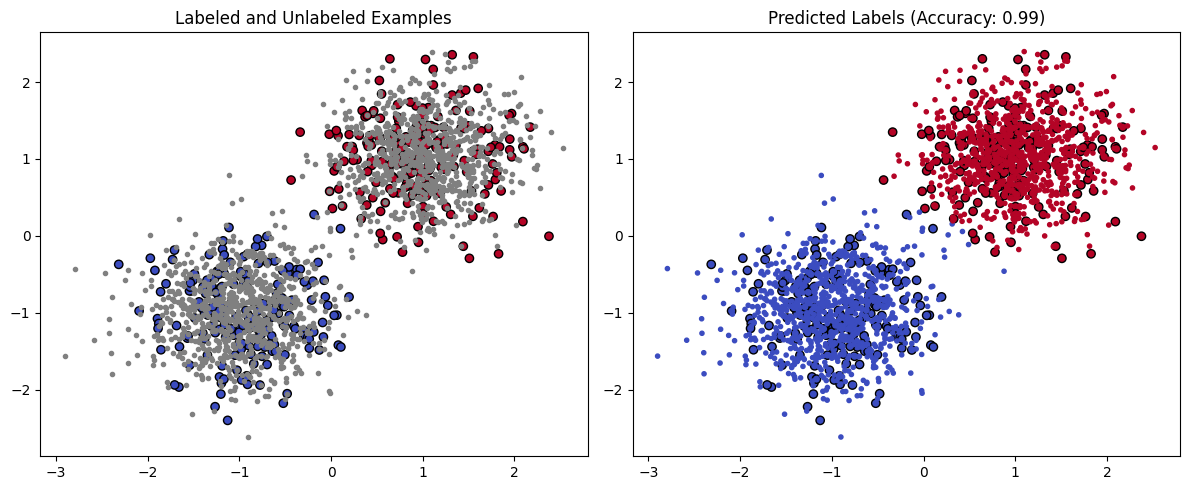

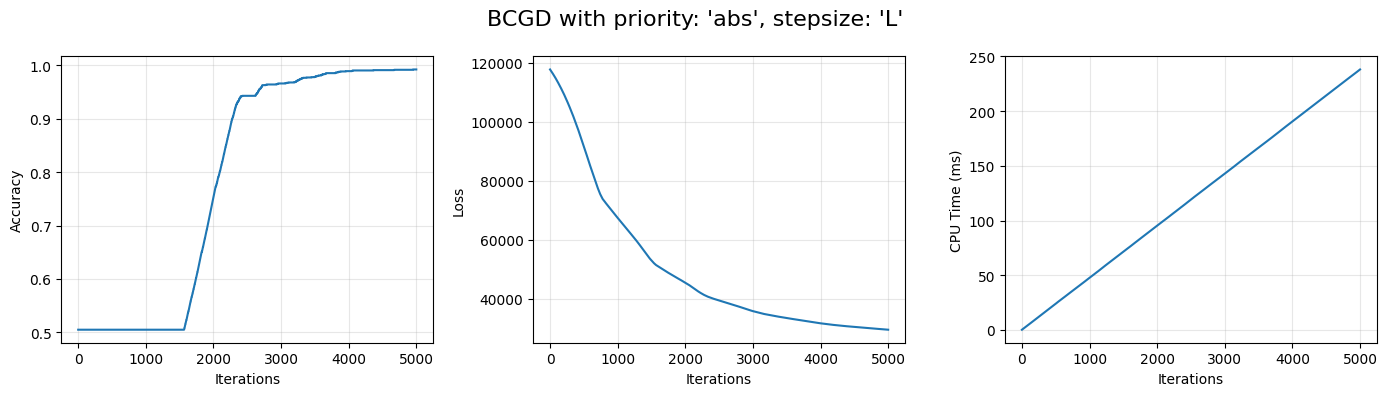

Running BCGD with priority strategy: 'abs', stepsize strategy: 'block_L'


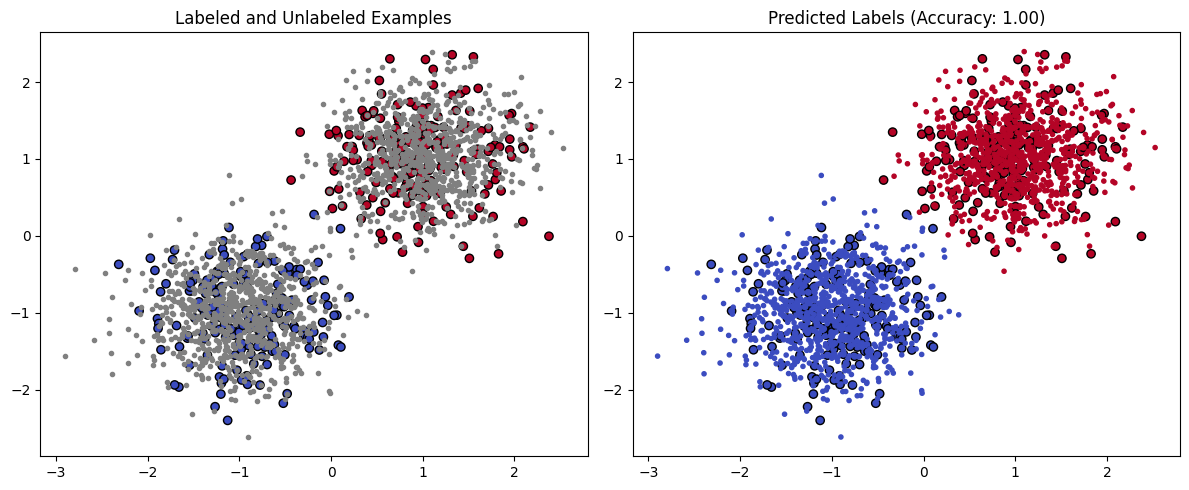

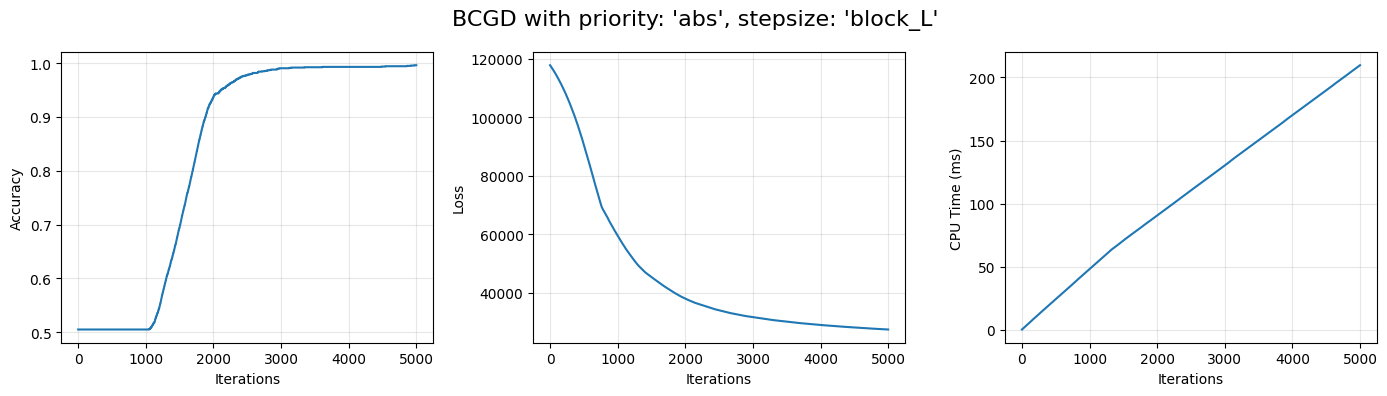

Running BCGD with priority strategy: 'abs', stepsize strategy: 'exact'


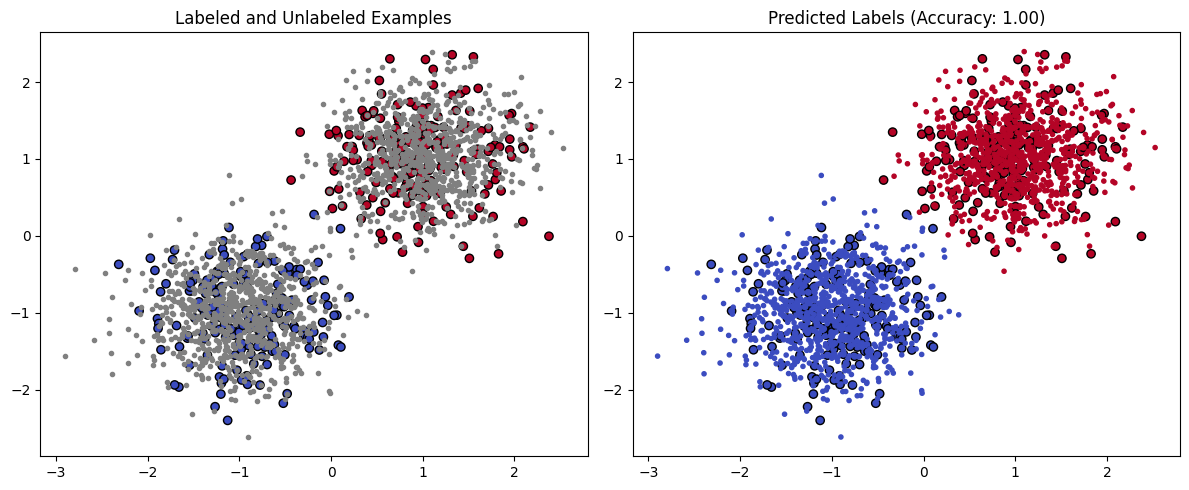

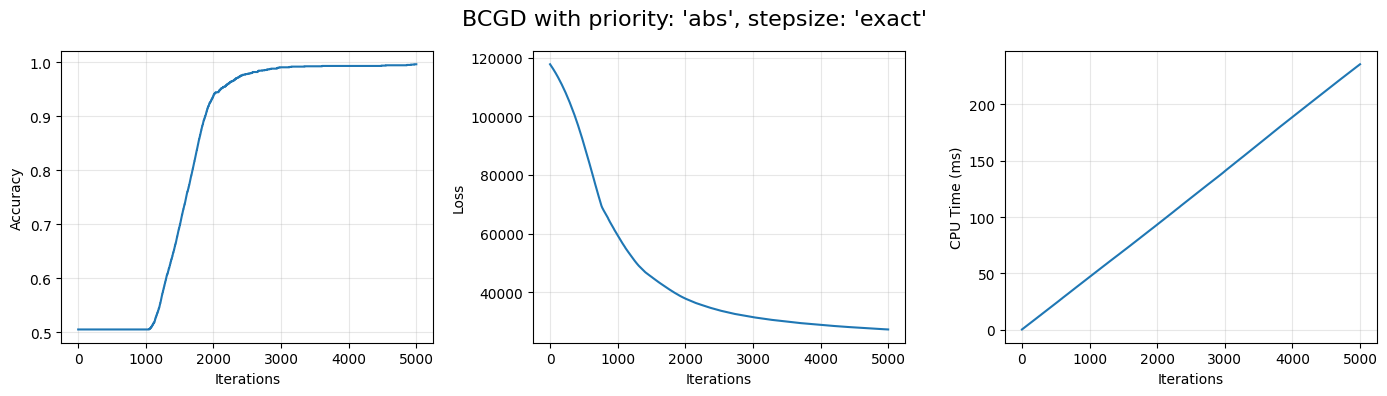

Running BCGD with priority strategy: 'abs', stepsize strategy: 'fixed'


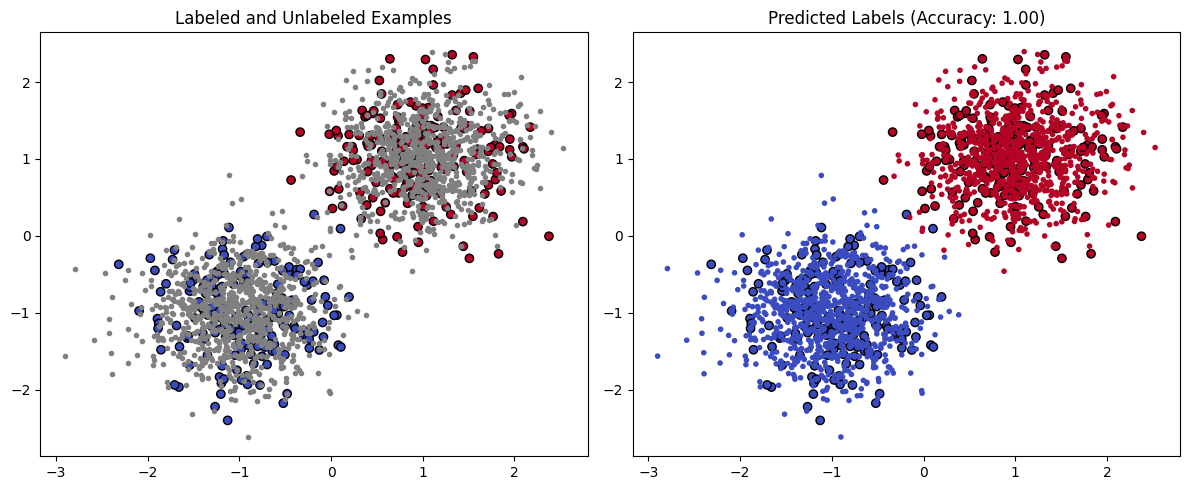

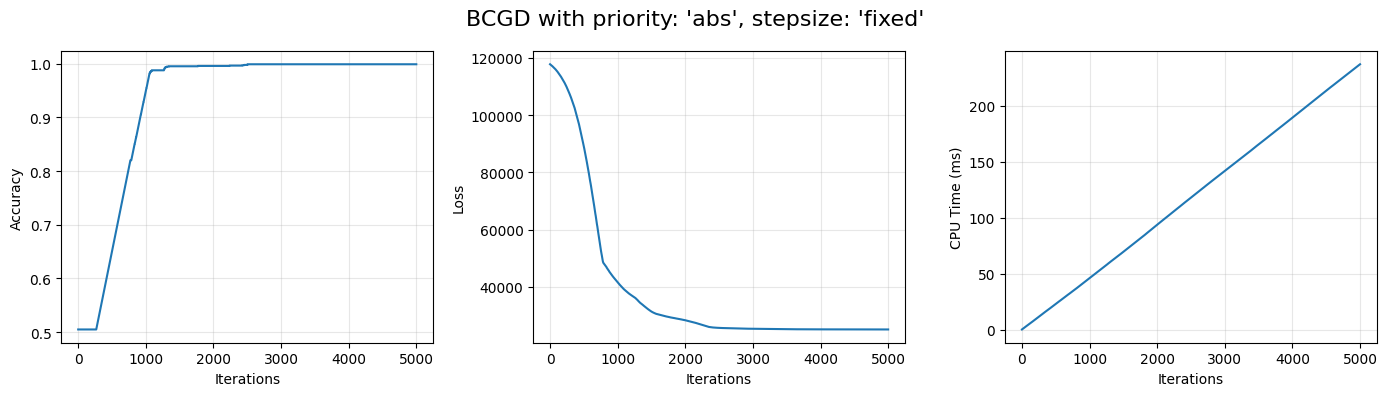

Running BCGD with priority strategy: 'abs_L', stepsize strategy: 'L'


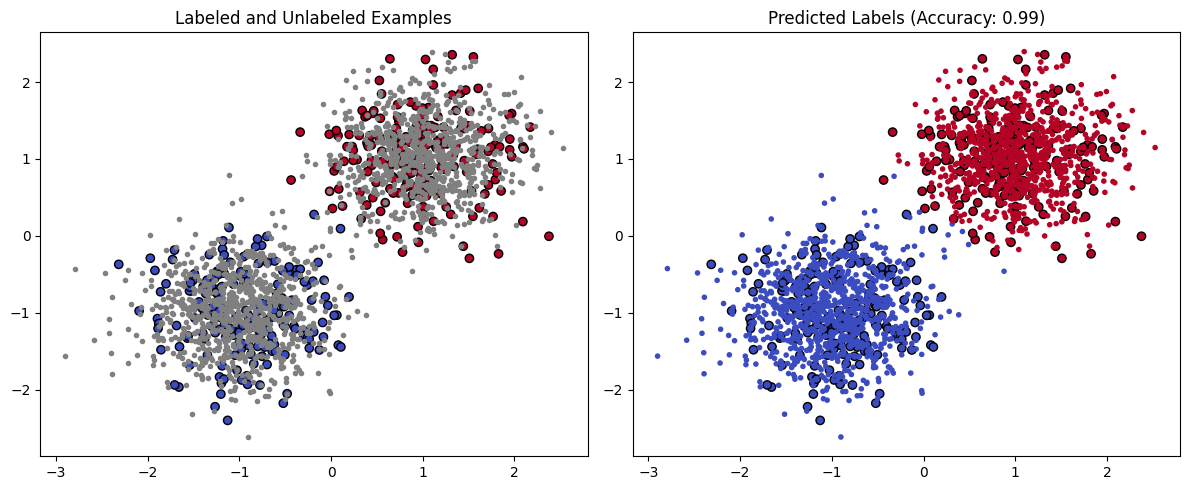

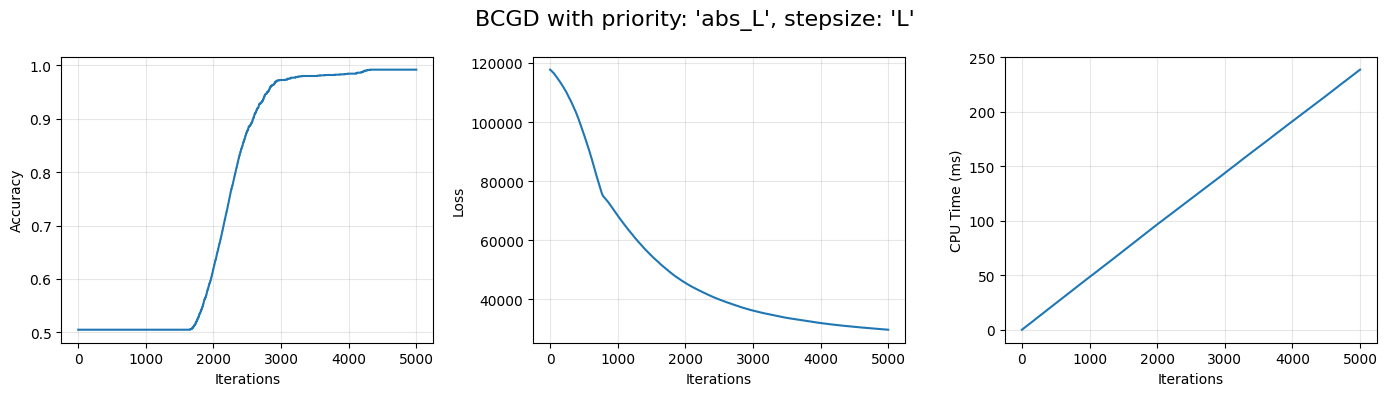

Running BCGD with priority strategy: 'abs_L', stepsize strategy: 'block_L'


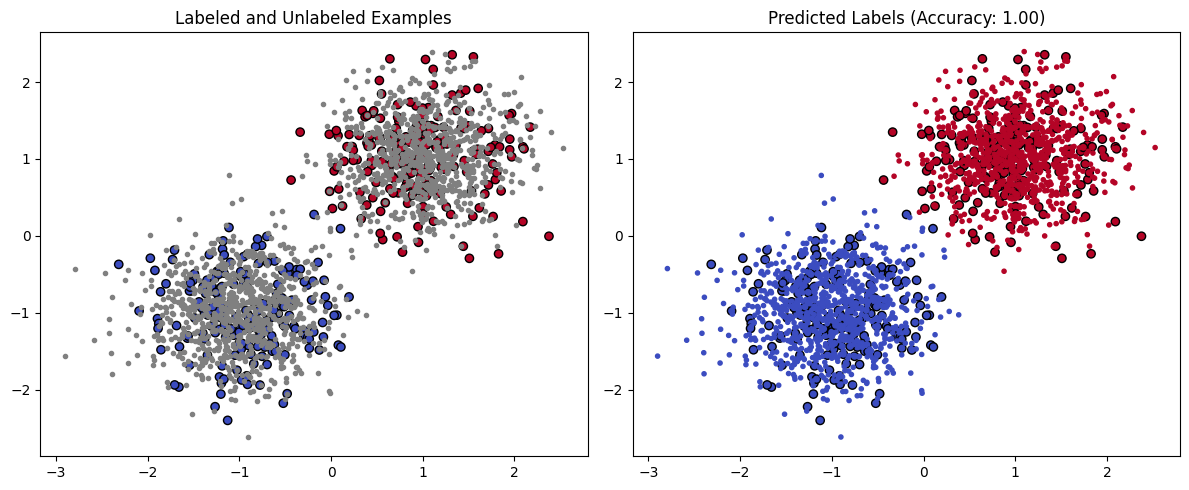

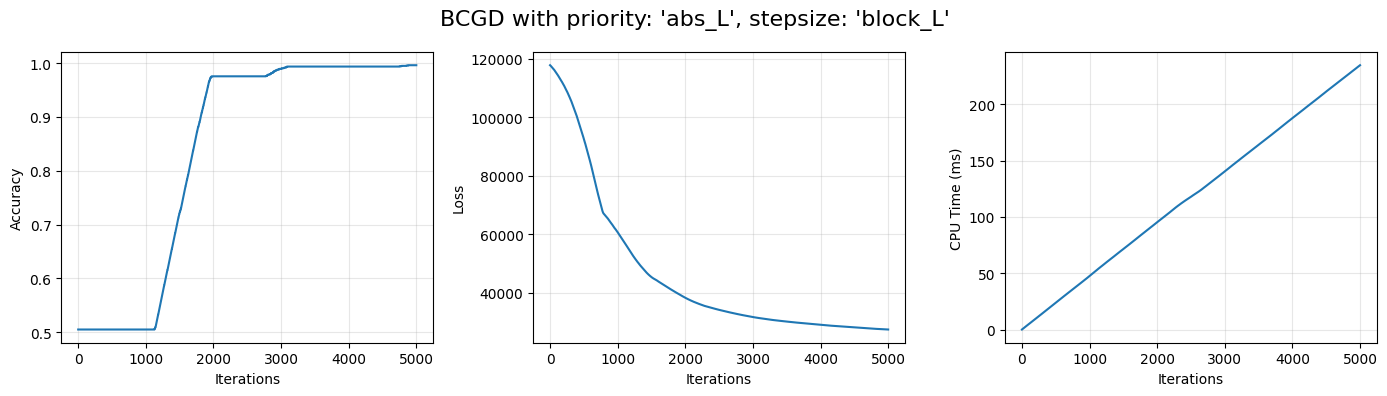

Running BCGD with priority strategy: 'abs_L', stepsize strategy: 'exact'


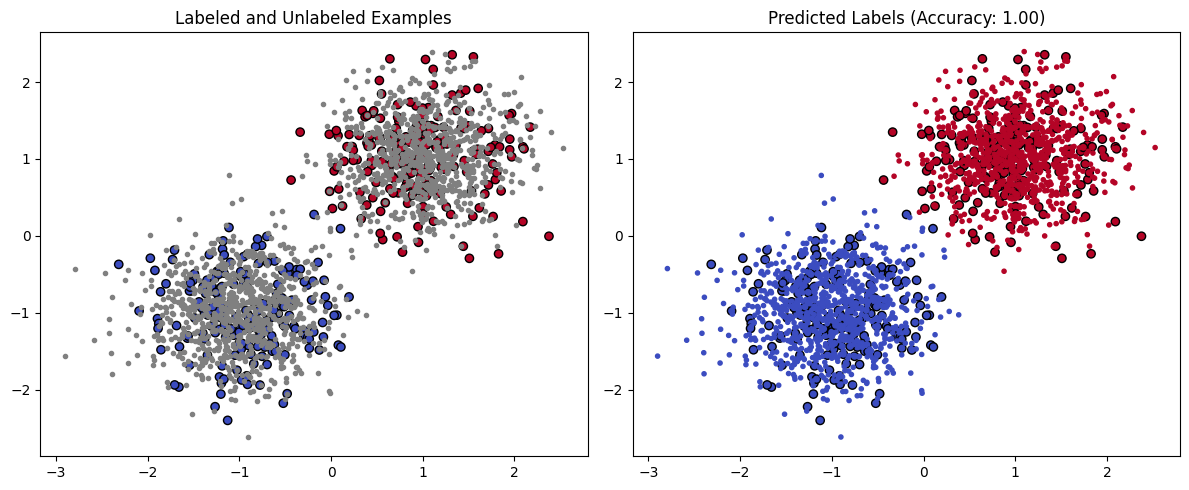

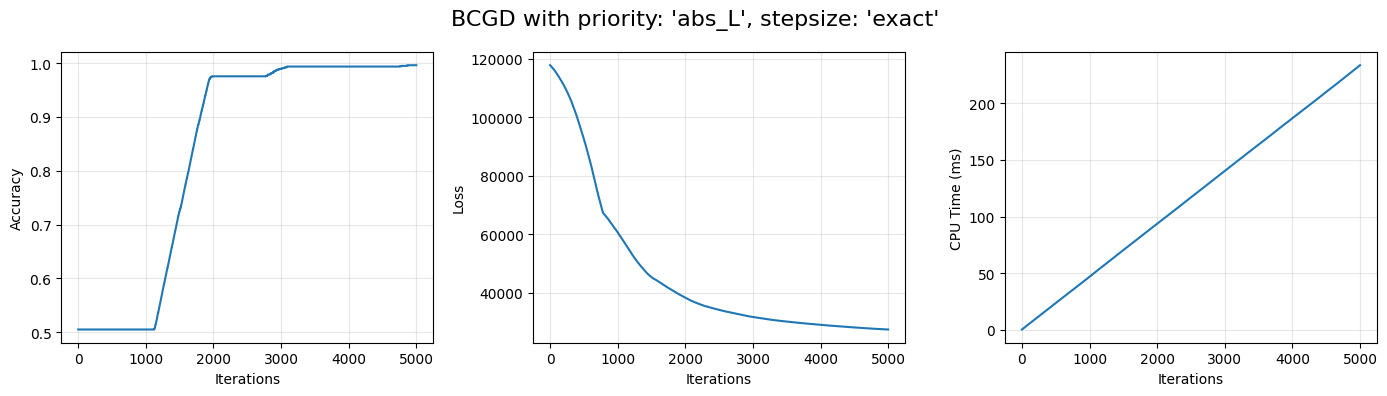

Running BCGD with priority strategy: 'abs_L', stepsize strategy: 'fixed'


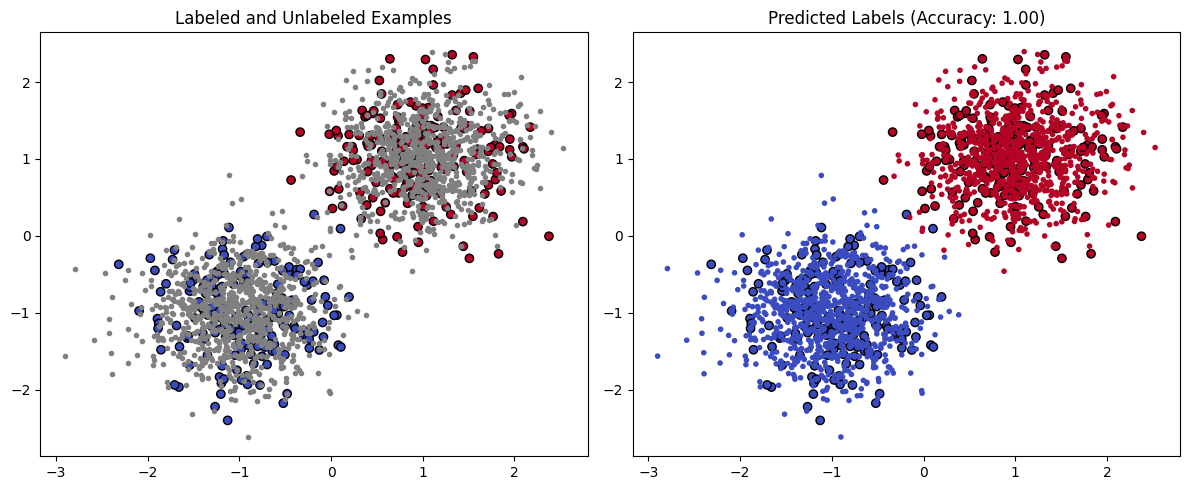

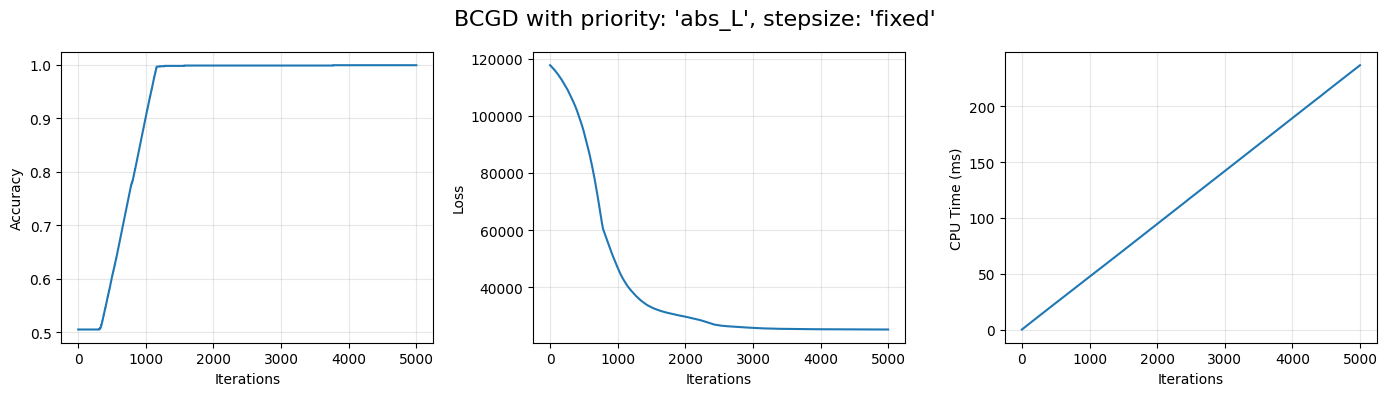

Running BCGD with priority strategy: 'max_improvement', stepsize strategy: 'L'


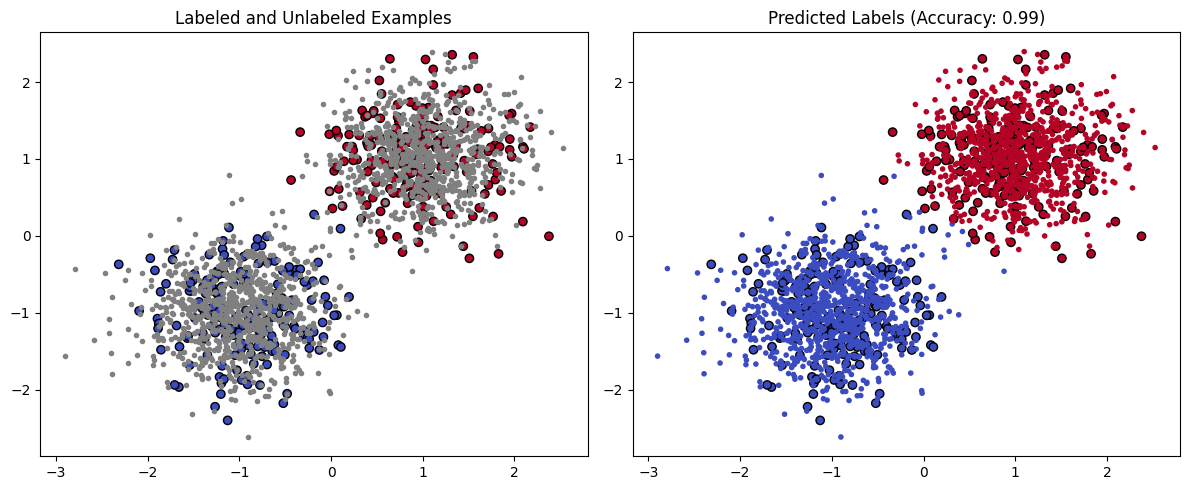

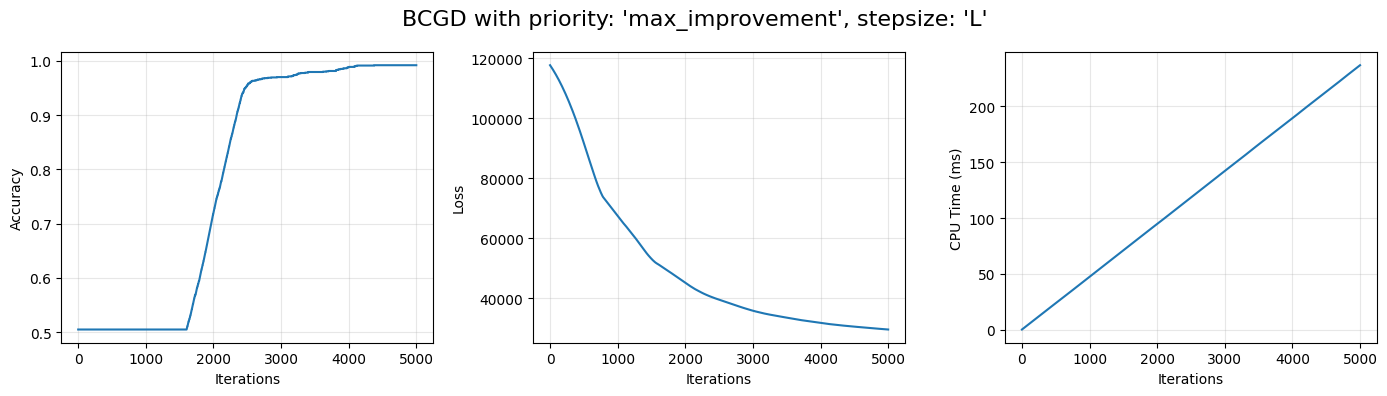

Running BCGD with priority strategy: 'max_improvement', stepsize strategy: 'block_L'


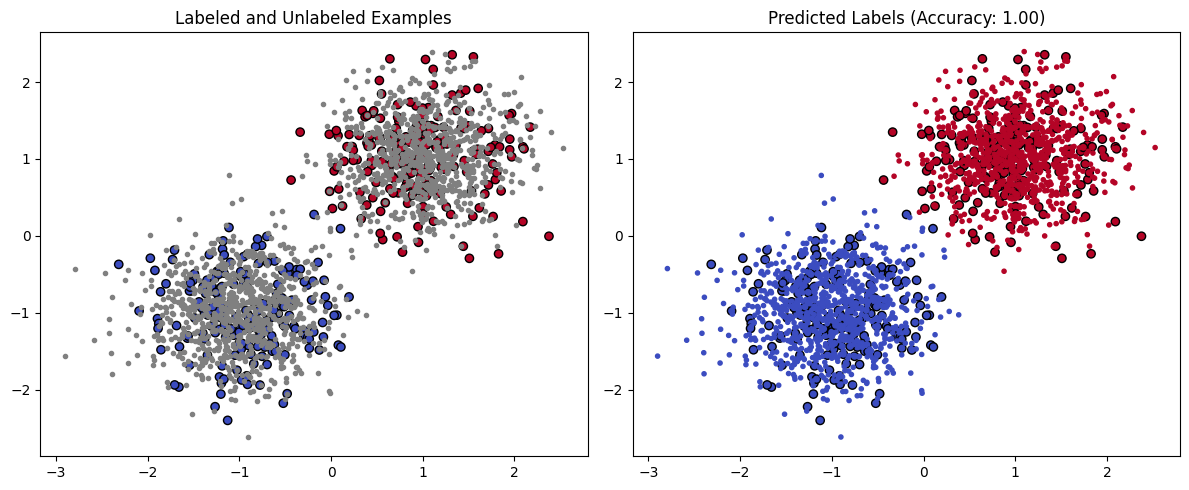

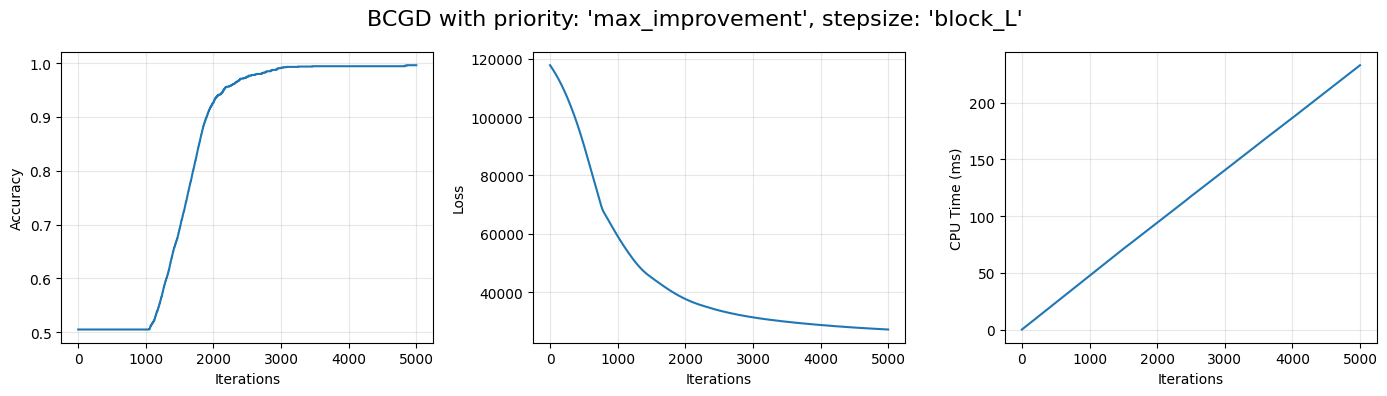

Running BCGD with priority strategy: 'max_improvement', stepsize strategy: 'exact'


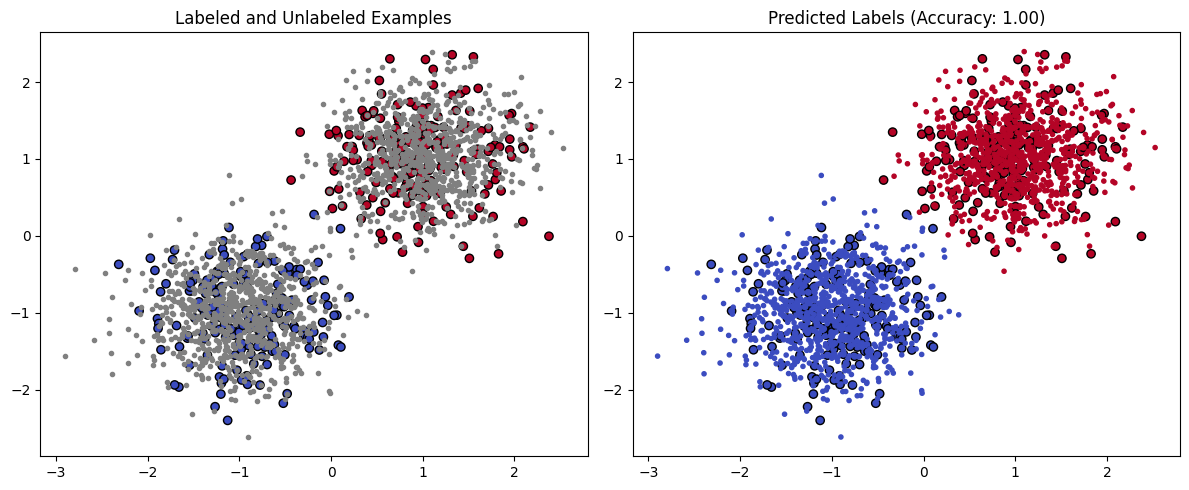

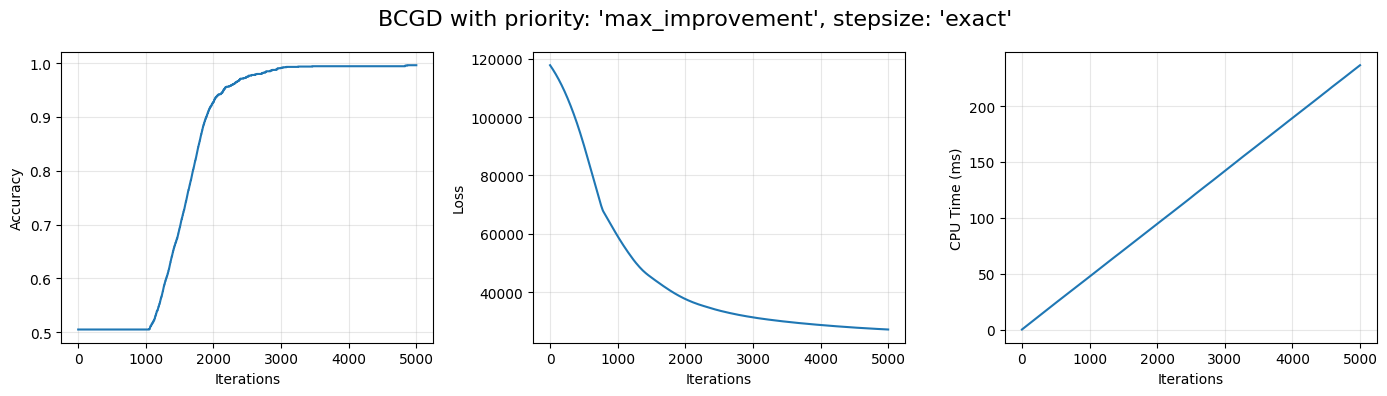

Running BCGD with priority strategy: 'max_improvement', stepsize strategy: 'fixed'


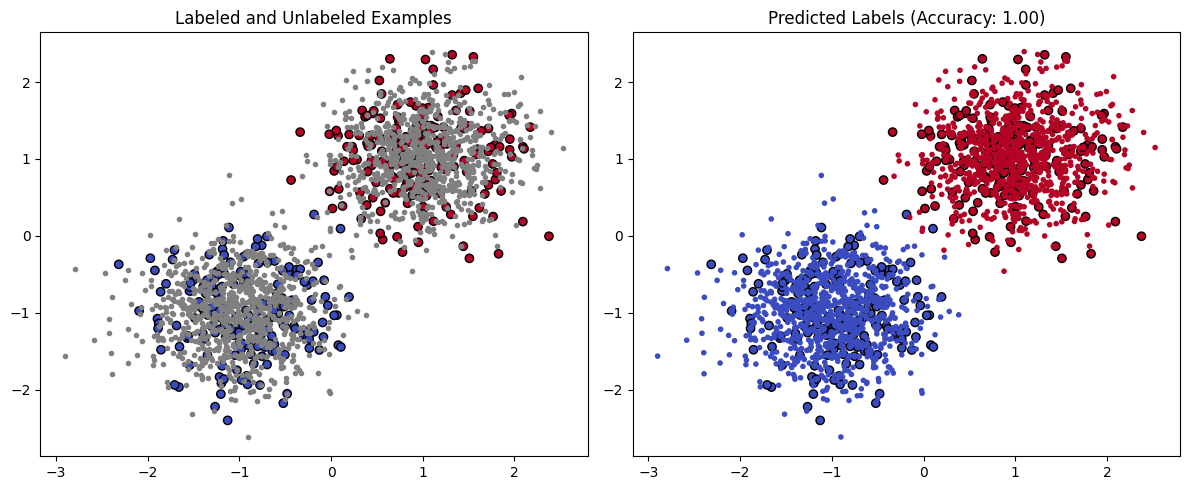

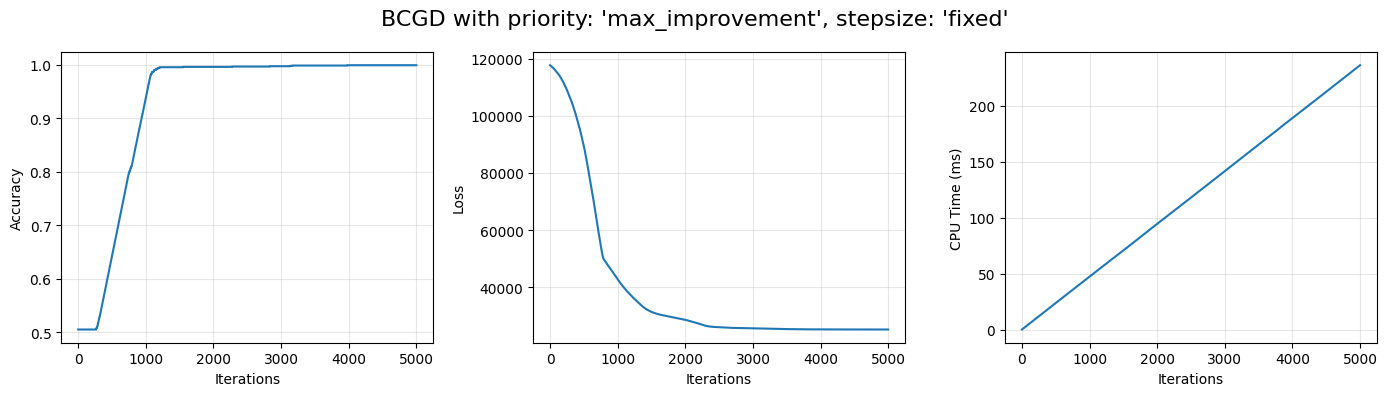

In [35]:
priority_strategies = [
    'abs', 
    'abs_L', 
    'max_improvement'
]
stepsize_strategies = [
    'L', 
    'block_L',
    'exact',
    'fixed'
]

for i, (priority_strat, stepsize_strat) in enumerate(itertools.product(priority_strategies, stepsize_strategies)):
    print(f"Running BCGD with priority strategy: '{priority_strat}', stepsize strategy: '{stepsize_strat}'")

    # Initialize the solver
    solver = BlockCoordinateGDSolver(
        similarity_function=rbf_kernel,
        max_iter=5000,
        tol=0.001,
        block_size=1,
        stepsize=0.001,
        priority_strat=priority_strat,
        stepsize_strat=stepsize_strat
    )

    # Fit the model and predict labels for unlabeled data
    y_pred = solver.fit(X_labeled, y_labeled, X_unlabeled, y_true)

    # Plot the dataset with predicted labels
    plot_dataset(
        X_labeled, y_labeled, X_unlabeled, 
        y_pred=y_pred, y_true=y_true
    )

    # Plot performance metrics
    plot_metrics(solver, title=f"BCGD with priority: '{priority_strat}', stepsize: '{stepsize_strat}'")

### Coordinate Minimization

y_pred[j] = (∑ W[i, j]*y[i] + ∑ W_tilde[i, j]*y[i]) / (∑ W[i, j] + ∑ W_tilde[i, j])

In [ ]:
class CoordinateMinimizationSolver(SemiSupervisedLearner):

    def __init__(self, similarity_function: Callable = None, threshold: float = 0.5, max_iter: int = 1000, tol: float = 0.0001, coordinate_selection='cyclic'):
        super().__init__(similarity_function, threshold, max_iter, tol)

        self.coordinate_selection = coordinate_selection    # cyclic | random

    def _coordinate_minimizer(self, y_pred: np.ndarray, j: int) -> float:
        """
        Find the minimizer for coordinate j while keeping others fixed

        y_pred[j] = (∑ W[i, j]*y[i] + ∑ W_tilde[i, j]*y[i]) / (∑ W[i, j] + ∑ W_tilde[i, j]) 

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples
        j: int
            Index of the coordinate to optimize

        Returns:
        --------
        y_j_optimal: float
            Optimal value for coordinate j
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        return (np.sum(self.W[:, j] * self.y_labeled) + np.sum(self.W_tilde[:, j] * y_pred)) / (np.sum(self.W[:, j]) + np.sum(self.W_tilde[:, j]))

    def _solve_optimization(self) -> np.ndarray:
        start_time = time.time()

        # Reset history lists
        self.loss_history = []
        self.cpu_time_history = []

        U = len(self.X_unlabeled)

        # Initial predictions
        y_pred = self.y_pred.copy()

        # Coordinate Minimization
        for i in range(self.max_iter):
            y_old = y_pred.copy()

            # Generate coordinate indices based on selection strategy
            if self.coordinate_selection == 'cyclic':
                coordinates = np.arange(U)
            elif self.coordinate_selection == 'random':
                coordinates = np.random.permutation(U)
            else:
                raise ValueError('Invalid coordinate selection strategy')

            # Update each coordinate
            for j in coordinates:
                y_pred[j] = self._coordinate_minimizer(y_pred, j)

            # Compute loss, accuracy, and CPU time
            self.loss_history.append(self.objective_function(y_pred))
            self.accuracy_history.append(self.get_accuracy(y_pred))
            self.cpu_time_history.append(time.time() - start_time)

            # Check convergence
            if np.linalg.norm(y_pred - y_old) < self.tol:
                break

        return (y_pred > self.threshold).astype(int)

## Part 2

GOOGLE DATASET SEARCH  (google search engine)
https://datasetsearch.research.google.com/

WIKIPEDIA PAGE ON DATASETS (wiki infos)

https://en.wikipedia.org/wiki/List_of_datasets_for_machine-learning_research

UCI DATASETS (ML repository)

https://archive.ics.uci.edu/ml/datasets.php

OTHER SOURCES

https://www.kaggle.com/datasets

https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html

https://www.cs.toronto.edu/~kriz/cifar.html

http://yann.lecun.com/exdb/mnist/

In [ ]:
# testing on the public dataset